# 실습 1: 텍스트 감지 (Text Detection)
**소요시간: 40분** | 난이도: ⭐⭐

## 학습 목표
1. `detect_document_text` API로 문서에서 텍스트를 추출합니다.
2. **Block 구조**를 이해하고 PAGE → LINE → WORD 계층을 탐색합니다.
3. BoundingBox로 텍스트 위치를 시각화합니다.

## API 개요: detect_document_text
```python
response = textract.detect_document_text(
    Document={'Bytes': <바이트>}  # 또는 {'S3Object': {'Bucket': ..., 'Name': ...}}
)
```
- 지원 포맷: **JPEG, PNG, PDF, TIFF**
- 반환값: `response['Blocks']` — Block 객체 리스트

### Block 타입 (이 API에서 반환)
| BlockType | 설명 |
|---|---|
| `PAGE` | 전체 페이지, CHILD로 LINE들을 가짐 |
| `LINE` | 텍스트 한 줄, CHILD로 WORD들을 가짐 |
| `WORD` | 개별 단어 |


문서 크기: 6,359 bytes
이미지 크기: 349x94 px


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


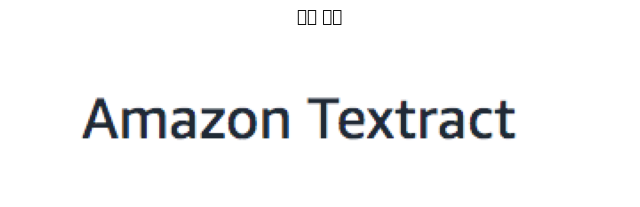

In [3]:
# ✅ [제공 코드] 환경 설정 (0-overview-setup.ipynb에서 실행했다면 생략 가능)
import boto3
import json
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import pandas as pd

textract = boto3.client('textract', region_name='ap-northeast-2')

IMAGE_DIR = './images/'
image_path = os.path.join(IMAGE_DIR, 'lab01_text.jpg')

def load_document_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

doc_bytes = load_document_bytes(image_path)
print(f"문서 크기: {len(doc_bytes):,} bytes")

# 원본 이미지 확인
img = Image.open(image_path)
print(f"이미지 크기: {img.size[0]}x{img.size[1]} px")
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis('off')
plt.title('원본 문서')
plt.show()


## ✏️ TODO 1: detect_document_text API 호출

문서에서 텍스트를 추출하세요.


In [5]:
# ✏️ TODO 1: API를 호출하고 전체 Block 수를 출력하세요
response = textract.detect_document_text(              # ← detect_document_text
    Document={
        'Bytes': doc_bytes               # ← 'Bytes'
    }
)

blocks = response['Blocks']               # ← 'Blocks'
print(f"전체 Block 수: {len(blocks)}개")
print(f"페이지 수: {response['DocumentMetadata']['Pages']}페이지")  # ← 'Pages'


전체 Block 수: 4개
페이지 수: 1페이지


## ✏️ TODO 2: Block 타입별 개수 분석

반환된 Blocks에서 각 BlockType의 개수를 집계하세요.


In [6]:
# ✏️ TODO 2: BlockType별 개수를 집계하여 출력하세요
# 힌트: 딕셔너리를 사용해 각 타입의 개수를 세어보세요

type_counts = {}  # 빈 딕셔너리 시작

for block in blocks:
    btype = block['BlockType']               # ← 'BlockType'
    type_counts[btype] = type_counts.get(btype, 0) + 1  # ← btype, 1

print("BlockType 분포:")
print("-" * 30)
for btype, count in sorted(type_counts.items()):
    print(f"  {btype:<20} {count:>5}개")


BlockType 분포:
------------------------------
  LINE                     1개
  PAGE                     1개
  WORD                     2개


## ✏️ TODO 3: LINE 블록에서 텍스트 추출

BlockType이 'LINE'인 블록만 필터링하여 텍스트를 출력하세요.


In [7]:
# ✏️ TODO 3: LINE 타입 블록의 텍스트를 출력하세요
lines = [b for b in blocks if b['BlockType'] == 'LINE']   # ← 'BlockType', 'LINE'

print(f"감지된 줄(LINE) 수: {len(lines)}개")
print("\n추출된 텍스트:")
print("=" * 50)
for i, line in enumerate(lines[:20]):   # 최대 20줄 출력
    text = line['Text']                  # ← 'Text'
    conf = line['Confidence']                  # ← 'Confidence'
    print(f"[{conf:.1f}%] {text}")

if len(lines) > 20:
    print(f"... (총 {len(lines)}줄 중 20줄 표시)")


감지된 줄(LINE) 수: 1개

추출된 텍스트:
[100.0%] Amazon Textract


## ✏️ TODO 4: Block 관계(Relationships) 탐색

LINE 블록의 `Relationships`를 통해 포함된 WORD들을 찾으세요.

**Block 관계 구조:**
```python
# LINE Block 예시
{
    'BlockType': 'LINE',
    'Text': 'Hello World',
    'Relationships': [
        {
            'Type': 'CHILD',
            'Ids': ['uuid-1', 'uuid-2']  # WORD Block들의 Id
        }
    ]
}
```


In [8]:
# ✅ [제공 코드] Id → Block 딕셔너리 생성 (관계 탐색용)
block_map = {block['Id']: block for block in blocks}
print(f"block_map 생성 완료: {len(block_map)}개 Block")


block_map 생성 완료: 4개 Block


In [9]:
# ✏️ TODO 4: 첫 번째 LINE의 WORD 블록들을 순서대로 출력하세요
first_line = lines[0]
print(f"선택한 LINE: '{first_line['Text']}'")
print("\n포함된 WORD 블록:")
print("-" * 40)

for rel in first_line.get('Relationships', []):
    if rel['Type'] == 'CHILD':           # ← 'Type'
        for word_id in rel['Ids']:      # ← 'Ids'
            word_block = block_map[word_id]   # ← word_id
            word_text = word_block['Text']   # ← 'Text'
            word_conf = word_block['Confidence']   # ← 'Confidence'
            print(f"  WORD: '{word_text}' (신뢰도: {word_conf:.1f}%)")


선택한 LINE: 'Amazon Textract'

포함된 WORD 블록:
----------------------------------------
  WORD: 'Amazon' (신뢰도: 100.0%)
  WORD: 'Textract' (신뢰도: 100.0%)


## ✏️ TODO 5: 전체 텍스트를 하나의 문자열로 재구성

LINE 블록들을 순서대로 이어 붙여 문서의 전체 텍스트를 재구성하세요.


In [10]:
# ✏️ TODO 5: 문서 전체 텍스트를 재구성하세요
# 힌트: LINE 블록의 Text를 개행('\n')으로 이어 붙이세요

full_text = '\n'.join([line['Text'] for line in lines])   # ← '\n'.join([line['Text'] for line in lines])

print("재구성된 전체 텍스트:")
print("=" * 50)
print(full_text[:500])  # 처음 500자 출력
print(f"\n총 문자 수: {len(full_text)}자")


재구성된 전체 텍스트:
Amazon Textract

총 문자 수: 15자


## ✏️ TODO 6: BoundingBox 시각화

LINE 블록의 위치를 이미지에 표시하세요.

**BoundingBox 좌표계:**
- `Left`, `Top`: 왼쪽 상단 꼭짓점 (0.0~1.0 비율)
- `Width`, `Height`: 너비와 높이 (0.0~1.0 비율)
- 실제 픽셀 = 비율 × 이미지 크기


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

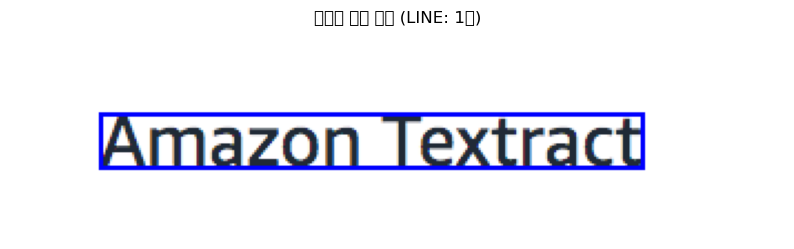

In [12]:
# ✏️ TODO 6: LINE 블록을 이미지 위에 파란 사각형으로 표시하세요
img = Image.open(image_path).convert('RGB')
draw = ImageDraw.Draw(img)
w, h = img.size

for line in lines:
    box = line['Geometry']['BoundingBox']        # ← 'BoundingBox'
    
    # 픽셀 좌표 계산
    left   = box['Left'] * w              # ← 'Left'
    top    = box['Top'] * h              # ← 'Top'
    right  = left + box['Width'] * w       # ← 'Width'
    bottom = top  + box['Height'] * h       # ← 'Height'
    
    draw.rectangle([left, top, right, bottom],
                   outline='blue', width=2)  # ← 색상: 'blue'

plt.figure(figsize=(10, 12))
plt.imshow(img)
plt.axis('off')
plt.title(f'텍스트 감지 결과 (LINE: {len(lines)}개)')
plt.show()


## ✏️ TODO 7: 신뢰도 낮은 텍스트 필터링

Confidence가 90% 미만인 텍스트를 찾아 별도 출력하세요.
이런 텍스트는 OCR 오류 가능성이 높아 후처리가 필요합니다.


In [13]:
# ✏️ TODO 7: Confidence < 90인 LINE을 필터링하여 출력하세요
low_conf_lines = [line for line in lines if line['Confidence'] < 90]  # ← 'Confidence', 90

print(f"신뢰도 90% 미만 줄: {len(low_conf_lines)}개")
if low_conf_lines:
    print("\n낮은 신뢰도 텍스트:")
    for line in low_conf_lines:
        print(f"  [{line['Confidence']:.1f}%] {line['Text']}")
else:
    print("모든 텍스트가 90% 이상의 신뢰도를 가집니다.")


신뢰도 90% 미만 줄: 0개
모든 텍스트가 90% 이상의 신뢰도를 가집니다.


## 💡 심화 도전
1. WORD 단위로 신뢰도 분포를 히스토그램으로 그려보세요.
2. 텍스트를 JSON 또는 CSV 파일로 저장하는 코드를 작성해보세요.
3. Polygon(다각형) 좌표를 이용해 기울어진 텍스트의 경계를 더 정확히 표시해보세요.
   - `block['Geometry']['Polygon']` 활용
